In [ ]:
import numpy as np
import os
import cv2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
import torch.nn as nn
from torchvision import models, transforms
import torch
import torchvision
from PIL import Image
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pickle
import torchvision.transforms.functional as TF
from time import time
from skorch import NeuralNetClassifier
import random
from tqdm import tqdm

In [ ]:
# setting up paths 
BASE = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

data_path = os.path.join(BASE, "data")

no_defect = os.listdir(os.path.join(data_path, "KGT_noDefect"))
pitting= os.listdir(os.path.join(data_path, "KGT_pitting"))

model_used = "cnn" # choose between resnet18 and cnn
resize = 150 # resnet 18 needs 224 picture size and cnn needs 150

<h1>Data Inspection </h1>

In [ ]:
root = os.path.join(BASE, "dataset")
# load the data
dataset = torchvision.datasets.ImageFolder(root=root)
# get the quantity of pitting and no pitting images
number_no_pitting = len(np.where(np.array(dataset.targets) == dataset.class_to_idx["False"])[0])
number_pitting = len(np.where(np.array(dataset.targets) == dataset.class_to_idx["True"])[0])

image_size = set()
image_mode = set()
# loop trough the dataset
for image, label in dataset:
    # use sets to only add unique values
    # check image size [width, height]
    image_size.add(image.size)
    # check the type of image e.g. RGB, grayscale
    # on first sight all images  seem to be RGB
    image_mode.add(image.mode)
    
# print all unique values for image size
print(image_size)
# print all unique values for image mode
print(image_mode)

{(143, 150), (146, 150), (127, 150), (116, 150), (144, 150), (117, 150), (150, 150), (119, 150), (148, 150)}
{'RGB'}


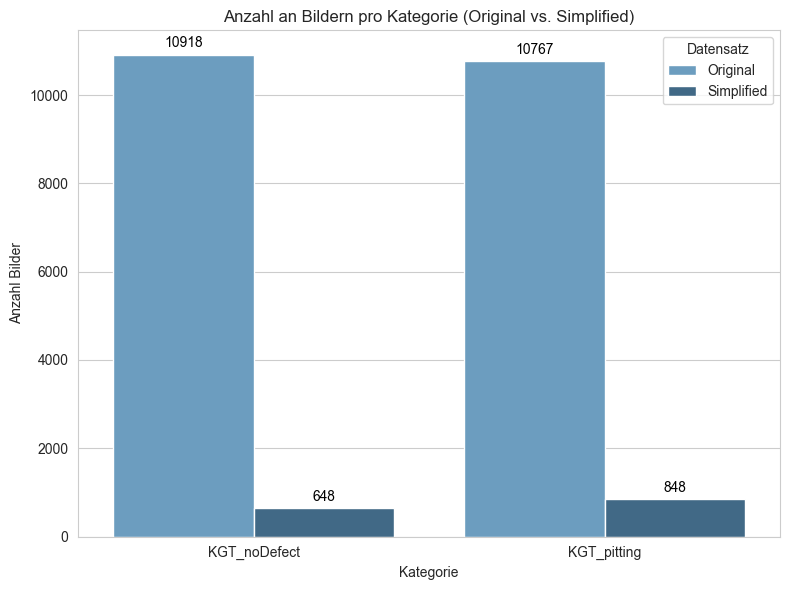

Original: 21685, Simplified: 1496


In [18]:
# Werte vorbereiten
df = pd.DataFrame({
    'Kategorie': ['KGT_noDefect', 'KGT_noDefect', 'KGT_pitting', 'KGT_pitting'],
    'Datensatz': ['Original', 'Simplified', 'Original', 'Simplified'],
    'Anzahl': [len(no_defect), 648, len(pitting), 848]
})

# Plot
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(
    x='Kategorie', y='Anzahl', hue='Datensatz',
    data=df, palette='Blues_d'
)

# Beschriftung
plt.title('Anzahl an Bildern pro Kategorie (Original vs. Simplified)')
plt.xlabel('Kategorie')
plt.ylabel('Anzahl Bilder')

for p in barplot.patches:
    height = int(p.get_height())
    if height != 0: 
        barplot.annotate(f'{height}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom',
                        fontsize=10, color='black',
                        xytext=(0, 3), textcoords='offset points')

plt.legend(title='Datensatz')
plt.tight_layout()
plt.show()

# Optional: Summen
original_total = len(no_defect) + len(pitting)
simplified_total = 648 + 848
print(f"Original: {original_total}, Simplified: {simplified_total}")

In [ ]:
# do it only for one channel at the same time because the 20000*150*150 datapoints will otherwise take up to much memory and it takes forever
# or use a subset like in the case below
r_values = []
g_values = []
b_values = []
sample_size = 2000 # size of sample used
indices = random.sample(range(len(dataset)), sample_size) # take #sample_size random pictures
for i in tqdm(indices, desc="Sampling for boxplots"):
    img, _ = dataset[i]
    img_np = np.array(img)
    # add the values of the pixels for each RGB channel
    r_values.extend(img_np[:, :, 0].flatten()) 
    g_values.extend(img_np[:, :, 1].flatten())
    b_values.extend(img_np[:, :, 2].flatten())

print(len(r_values))

Sampling for boxplots: 100%|██████████| 21685/21685 [00:32<00:00, 669.21it/s]

487891500


In [ ]:
max_values = []
min_values = []
q1_list = []
q3_list = []
median = []
# loop trough each channel to get key metrics like min, max, q1, q3 and median => save them for boxplot creation
# also calculate the iqr and check for outliers
for channel in tqdm([r_values, g_values, b_values], desc="plot boxplot"):
    channel = r_values
    print("data loaded")
    q1 = np.percentile(channel, 25)
    print("q1 finished")
    q3 = np.percentile(channel, 75)
    print("q3 finished")
    median.append(np.median(channel))
    print("median finished")
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    channel_max = max(channel)
    print("max finished")
    channel_min = min(channel)
    print("min finished")
    print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, max_value: {channel_max}, min_value: {channel_min}")
    print(f"max_value is outlier for factor {(channel_max-q3)/iqr}")
    print(f"min_value is outlier for factor {-(channel_min-q1)/iqr}")
    max_values.append(channel_max)
    min_values.append(channel_min)
    q1_list.append(q1)
    q3_list.append(q3)

data loaded
q1 finished
q3 finished
median finished
max finished
min finished
Q1: 80.0, Q3: 174.0, IQR: 94.0, max_value: 255, min_value: 0
max_value is outlier for factor 0.8617021276595744
min_value is outlier for factor 0.851063829787234


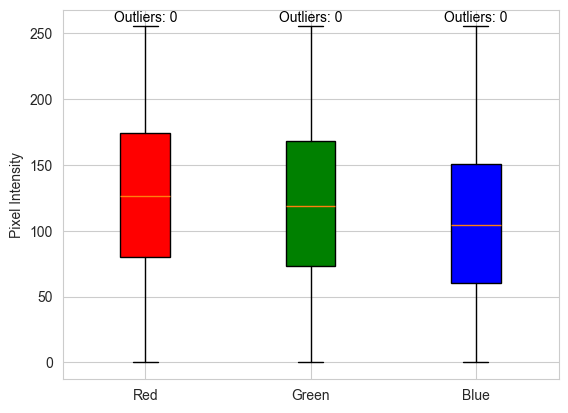

In [ ]:
# dictionary with charateristic values for each channel to make a boxplot
r_stats = {
    'label': 'Red',
    'whislo': min_values[0],   # Min
    'q1': q1_list[0],       # Q1
    'med': median[0],     # Median
    'q3': q3_list[0],      # Q3
    'whishi': max_values[0],  # Max
}

g_stats = {
    'label': 'Green',
    'whislo': min_values[1],   # Min
    'q1': q1_list[1],       # Q1
    'med': median[1],     # Median
    'q3': q3_list[1],      # Q3
    'whishi': max_values[1],  # Max
}

b_stats = {
    'label': 'Blue',
    'whislo': min_values[2],   # Min
    'q1': q1_list[2],       # Q1
    'med': median[2],     # Median
    'q3': q3_list[2],      # Q3
    'whishi': max_values[2],  # Max
}

# Combine stats and display the boxplot
rgb_stats = [r_stats, g_stats, b_stats]
fig, ax = plt.subplots()
box = ax.bxp(rgb_stats, showfliers=False, patch_artist=True)
colors = ['red', 'green', 'blue']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')

for i, stats in enumerate(rgb_stats):
    top_y = int(stats['whishi'])  # Prevent overflow
    ax.text(i + 1, top_y + 1, 'Outliers: 0',
            ha='center', va='bottom', fontsize=10, color='black')

plt.ylabel("Pixel Intensity")
plt.grid(True)
plt.show()


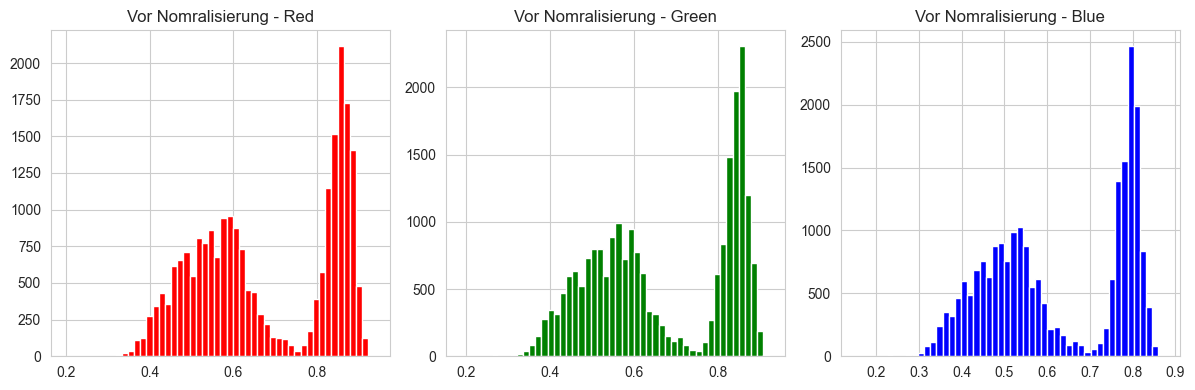

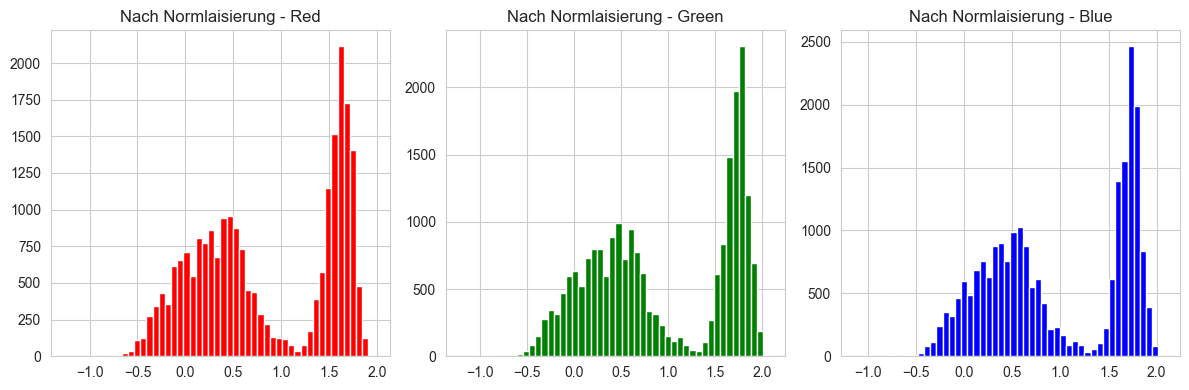

In [ ]:
# should we keep this???


img_path = os.path.join(data_path, "KGT_noDefect", no_defect[0])
img = Image.open(img_path)
# Define transforms
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], #values used in pretraining 
    std=[0.229, 0.224, 0.225]
)

# Apply transformations
tensor_img = to_tensor(img)
normalized_img = normalize(tensor_img)

# Plot histograms
def plot_histogram(tensor, title):
    plt.figure(figsize=(12, 4))
    channels = ['Red', 'Green', 'Blue']
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.hist(tensor[i].flatten().numpy(), bins=50, color=channels[i].lower())
        plt.title(f'{title} - {channels[i]}')
    plt.tight_layout()
    plt.show()

plot_histogram(tensor_img, "Vor Nomralisierung")
plot_histogram(normalized_img, "Nach Normlaisierung")

<h1> Model Training <h1>

In diesem Abschnitt implementieren wir ein vortrainiertes Convolutional Neural Network (CNN) und passen es an unseren Datensatz an (Finetuning). Dabei verwenden wir ResNet-18 von Microsoft, ein bewährtes Modell, das in unserem Bericht ausführlicher beschrieben wird.
Zur Untersuchung des Einflusses von Datenaugmentation werden die Eingabebilder in drei Varianten verarbeitet: zunächst mit minimalen Transformationen, anschließend mit moderater und schließlich mit starker Augmentierung. Die Ergebnisse dieser drei Varianten vergleichen wir anschließend hinsichtlich ihrer Modell-Performance.

### Transformationspipeline für Trainingsdaten

Diese Bildtransformationen werden verwendet, um das Modell robuster und generalisierungsfähiger zu machen:

- **Resize(256)**: Skaliert die kürzeste Seite des Bildes auf 256 Pixel, um eine einheitliche Ausgangsgröße zu schaffen.
- **RandomResizedCrop(224)**: Schneidet zufällig einen Bereich aus dem Bild aus und skaliert ihn auf 224×224 Pixel. Dies simuliert verschiedene Zoom- und Zuschnittsituationen. Die Größe von 224x224 Pixel wurde gewählt, da ResNet, so wie viele andere (vortrainierte) CNN diese Inputgröße erwarten
- **RandomHorizontalFlip()**: Spiegelt das Bild zufällig horizontal (mit 50 % Wahrscheinlichkeit), um Symmetrie zu nutzen.
- **ColorJitter**:
  - `brightness=0.2`: Zufällige Helligkeit (±20 %)
  - `contrast=0.2`: Zufälliger Kontrast (±20 %)
  - `saturation=0.2`: Zufällige Farbsättigung (±20 %)
  - `hue=0.05`: Zufälliger Farbton (±5 %)
 
  Diese Veränderung der Farben erhöht die Vielfalt künstlich.
- **RandomRotation(10)**: Rotiert das Bild zufällig im Bereich von ±10°, um leichte Schräglagen zu simulieren.
- **ToTensor()**: Konvertiert das PIL-Bild in einen PyTorch-Tensor im Format **CHW** (`[Channels, Height, Width]`) und skaliert die Werte in den Bereich [0.0, 1.0].
- **Normalize(mean, std)**: Wendet eine Normalisierung mit den **ImageNet-Statistiken** an (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`), damit das Modell die gleichen Datenverteilungen wie beim Pretraining sieht.

> Ziel: Diese Pipeline hilft dem Modell, sich nicht auf bestimmte Bildpositionen, -farben oder -ausrichtungen zu verlassen und dadurch robuster zu werden. Wir werden im folgenden drei verschiedenen Transformationen definieren, die eine (Teil-)Menge der Beschriebenen Funktionenn enthalten 


<h2> Festlgung der Transformationen </h2>

Für die Trainings-/Validierungs-Daten wurde eine andere Transformation gewählt als für die Test-Daten. Der Grund hierfür ist, dass das Laden der Daten aus dem jeweiligen Datensatz lazy passiert. Die Daten werden nicht vor dem Laden in den definierten Test-Datenstz transformiert, sondern erst wenn sie tatsächlich gebracht werden. Damit ist das Laden von Bilddaten (Tensoren) aufgrund der stochastischen Operationen (RandomReistedCrop, RandomHorizontalFlip etc.) nicht deterministisch, wodurch die Performance-Metrics bei mehrfachem Testen leicht unterschiedlch wären. Deshalb definieren wir für den Testdatensatz deterministische Transformatoren, um Replizierbarkeit zu gewährleisten.

Würde man auch bei den Test Bildern stochastische Transformationen anwenden, wären die Ergebnisse zwar robuster, aber nicht (so gut) reproduzierbar

In [5]:
# Training & Validierung 

# Light
train_transform_light = transforms.Compose([
    transforms.Resize(int(resize*1.1)),
    transforms.CenterCrop(resize),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Medium
train_transform_medium = transforms.Compose([
    transforms.Resize(int(resize*1.1)),
    transforms.CenterCrop(resize),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Strong
train_transform_strong = transforms.Compose([
    transforms.Resize(int(resize*1.1)),
    transforms.CenterCrop(resize),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Test 

# Light
test_transform = transforms.Compose([
    transforms.Resize(int(resize*1.1)),
    transforms.CenterCrop(resize),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Datensätze separat laden
def load_full_datasets(transformation: str): 
    transform = {
        "light" : [train_transform_light, test_transform], 
        "medium" : [train_transform_medium, test_transform], 
        "strong" : [train_transform_strong, test_transform]
    }
    full_dataset_train_val = datasets.ImageFolder(
        root=root, transform=transform[transformation][0])

    full_dataset_test = datasets.ImageFolder(
        root=root, transform=transform[transformation][1])
    
    return full_dataset_train_val, full_dataset_test


In [7]:
full_dataset_train_val_light, full_dataset_test_light = load_full_datasets("light")
full_dataset_train_val_medium, full_dataset_test_medium = load_full_datasets("medium")
full_dataset_train_val_strong, full_dataset_test_strong = load_full_datasets("strong")

In [8]:
def make_split(train_val, test): 

    # Aufteilen
    total_size = len(train_val)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    # Split-Indices
    generator = torch.Generator().manual_seed(42)
    train_val_indices = torch.randperm(total_size, generator=generator)

    # Subsets (verwende die gleichen Indices!)
    train_indices = train_val_indices[:train_size]
    val_indices = train_val_indices[train_size:train_size + val_size]
    test_indices = train_val_indices[train_size + val_size:]

    # Trainings- & Validierungssets mit augmentierten Daten
    train_dataset = torch.utils.data.Subset(train_val, train_indices)
    val_dataset = torch.utils.data.Subset(train_val, val_indices)

    # Testset mit deterministischen Daten
    test_dataset = torch.utils.data.Subset(test, test_indices)

    return train_dataset, val_dataset, test_dataset

In [9]:
train_set_light, val_set_light, test_set_light = make_split(full_dataset_train_val_light, full_dataset_test_light)
train_set_medium, val_set_medium, test_set_medium = make_split(full_dataset_train_val_medium, full_dataset_test_medium)
train_set_strong, val_set_strong, test_set_strong = make_split(full_dataset_train_val_strong, full_dataset_test_strong)

In [10]:
def make_loader(train_set, val_set, test_set): 
    train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

    return train_loader, val_loader, test_loader

In [11]:
train_loader_light, val_loader_light, test_loader_light = make_loader(train_set_light, val_set_light, test_set_light)
train_loader_medium, val_loader_medium, test_loader_medium = make_loader(train_set_medium, val_set_medium, test_set_medium)
train_loader_strong, val_loader_strong, test_loader_strong = make_loader(train_set_strong, val_set_strong, test_set_strong)

In [ ]:
class Net(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 34 * 34, 2048)
        self.fc2 = nn.Linear(2048, 256)
        self.fc3 = nn.Linear(256, 32)
        self.fc4 = nn.Linear(32, 2)
        # Dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))
        x = self.fc4(x)
        return x

In [16]:
def save_model(model, transformation): 
    torch.save(model.state_dict(), os.path.join(BASE, "models",  f"{model_used}_pitting_not_simplified_{transformation}.pth"))

def save_metrics(train_losses: list, val_losses: list, train_time, transformation: str): 
    losses = {
        "train_loss": train_losses, 
        "val_loss": val_losses,
        "train_time": train_time
    }

    # path 
    save_path = os.path.join(BASE, "models", f"{model_used}_metrics_{transformation}.pkl")

    # save
    with open(save_path, "wb") as f:
        pickle.dump(losses, f)

def load_metrics(transformation: str = None): 
    filename = f"{model_used}_metrics_{transformation}.pkl" if transformation else "metrics.pkl"
    load_path = os.path.join(BASE, "models", filename)

    # Laden
    with open(load_path, "rb") as f:
        metrics = pickle.load(f)
    
    return metrics

def train_model(train_loader, val_loader, transformation: str, device, model_used, num_epochs): 
    if model_used == "resnet18":
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, 2)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        model.to(device)
    else: 
        model = Net(dropout=0.2)
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
        model.to(device)

    criterion = nn.CrossEntropyLoss()
    

    # Training loop with validation
    num_epochs = num_epochs
    train_losses = []
    val_losses = []

    t1 = time() 

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        train_losses.append(running_train_loss)

        # Validation loop
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        val_losses.append(running_val_loss)

        print(f"Epoch {epoch+1} | Train Loss: {running_train_loss:.4f} | Val Loss: {running_val_loss:.4f}")
    
    t2 = time() 

    train_time = t2 - t1

    save_model(model, transformation)
    save_metrics(train_losses, val_losses, train_time, transformation)

    return model

In [17]:
model_params = {
    "light": [train_loader_light, val_loader_light], 
    "medium": [train_loader_medium, val_loader_medium], 
    "strong": [train_loader_strong, val_loader_strong]
}

trained_models = []
device = "cpu" # torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else
print(f"Using {device} device")

num_epochs = 15
for transformation in model_params.keys(): 
    train_loader = model_params[transformation][0]
    val_loader = model_params[transformation][1]
    trained_model = train_model(train_loader, val_loader, transformation, device, model_used, num_epochs)
    trained_models.append(trained_model)

Using cpu device
Epoch 1 | Train Loss: 498.8031 | Val Loss: 86.4627
Epoch 2 | Train Loss: 363.2975 | Val Loss: 72.1068
Epoch 3 | Train Loss: 310.0187 | Val Loss: 64.3283
Epoch 4 | Train Loss: 274.6425 | Val Loss: 58.7242
Epoch 5 | Train Loss: 237.3778 | Val Loss: 44.7779
Epoch 6 | Train Loss: 206.6058 | Val Loss: 60.1550
Epoch 7 | Train Loss: 168.1986 | Val Loss: 36.9484
Epoch 8 | Train Loss: 132.5053 | Val Loss: 32.3358
Epoch 9 | Train Loss: 106.8289 | Val Loss: 56.9650
Epoch 10 | Train Loss: 88.4148 | Val Loss: 29.4036
Epoch 11 | Train Loss: 72.6197 | Val Loss: 30.6549
Epoch 12 | Train Loss: 56.3592 | Val Loss: 34.0816
Epoch 13 | Train Loss: 45.7213 | Val Loss: 48.1033
Epoch 14 | Train Loss: 39.5392 | Val Loss: 32.0205
Epoch 15 | Train Loss: 29.9045 | Val Loss: 32.8780
Epoch 1 | Train Loss: 481.4333 | Val Loss: 86.5676
Epoch 2 | Train Loss: 382.8265 | Val Loss: 74.4723
Epoch 3 | Train Loss: 346.6572 | Val Loss: 65.7272
Epoch 4 | Train Loss: 313.7829 | Val Loss: 110.6727
Epoch 5 | Tra

In [19]:
def plot_losses(losses, transformation):
    epochs = list(range(1, len(losses["train_loss"]) + 1))
    
    df = pd.DataFrame({
        "Epoche": epochs * 2,
        "Loss": losses["train_loss"] + losses["val_loss"],
        "Typ": ["Training"] * len(epochs) + ["Validierung"] * len(epochs)
    })
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Epoche", y="Loss", hue="Typ", style="Typ", markers=True, dashes=False)

    plt.title(f"Verlust (Loss) pro Epoche | Transformation: {transformation}", fontsize=14)
    plt.xlabel("Epoche", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(title="Datentyp", loc="upper right")
    plt.tight_layout()
    plt.show()

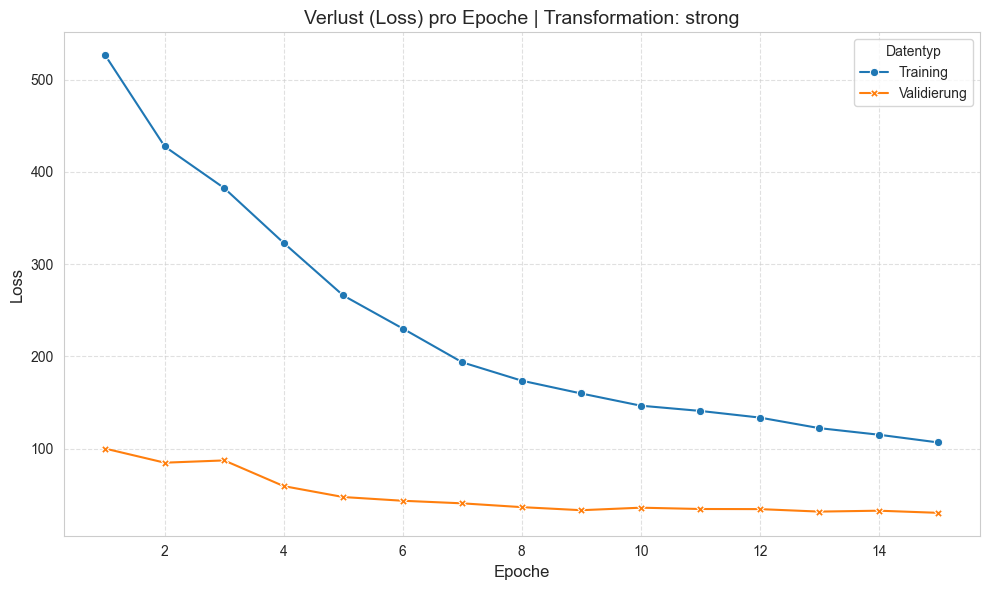

In [22]:
losses = load_metrics("strong")
testfig = plot_losses(losses, "strong")

In [23]:
#load model
def load_model(transformation: str = None): 
    if model_used == "resnet18":
        model = models.resnet18(pretrained=False)
        model.fc = torch.nn.Linear(model.fc.in_features, 2)  # 2 classes
        filename = f"{model_used}_pitting_not_simplified_{transformation}.pth" if transformation else f"{model_used}_pitting_not_simplified.pth"
        load_path = os.path.join(BASE, "models", filename)
    else:
        model = Net()
        filename = f"cnn_pitting_not_simplified_{transformation}.pth" if transformation else "cnn_pitting_not_simplified.pth"
        load_path = os.path.join(BASE, "models", filename)
    model.load_state_dict(torch.load(load_path))
    device = "cpu" # torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 
    model.to(device) 
    return model 

<h1> Testing </h1> 

In [24]:
light_model = load_model("light")
medium_model = load_model("medium")
strong_model = load_model("strong")


In [25]:
time_light = load_metrics("light")["train_time"] /60
time_medium = load_metrics("medium")["train_time"] /60
time_strong = load_metrics("strong")["train_time"] /60

print(time_light, time_medium, time_strong)

33.87470121781031 69.36037693421046 46.83109795252482


In [26]:
def test_model(model, test_loader, class_names=None, return_metrics=False):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # metrics
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, digits=4)

    print(f"Test Accuracy: {acc:.4f}")
    print("\n Classification Report:")
    print(report)

    # Confusion matrix 
    plt.figure(figsize=(8, 6))
    try: 
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
    except: 
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Vorhergesagte Klasse")
    plt.ylabel("Wahre Klasse")
    plt.title("Konfusionsmatrix")
    plt.tight_layout()
    plt.show()

    if return_metrics:
        return acc, cm, report

Test Accuracy: 0.9619

 Classification Report:
              precision    recall  f1-score   support

           0     0.9731    0.9522    0.9625      1672
           1     0.9506    0.9722    0.9613      1582

    accuracy                         0.9619      3254
   macro avg     0.9618    0.9622    0.9619      3254
weighted avg     0.9621    0.9619    0.9619      3254



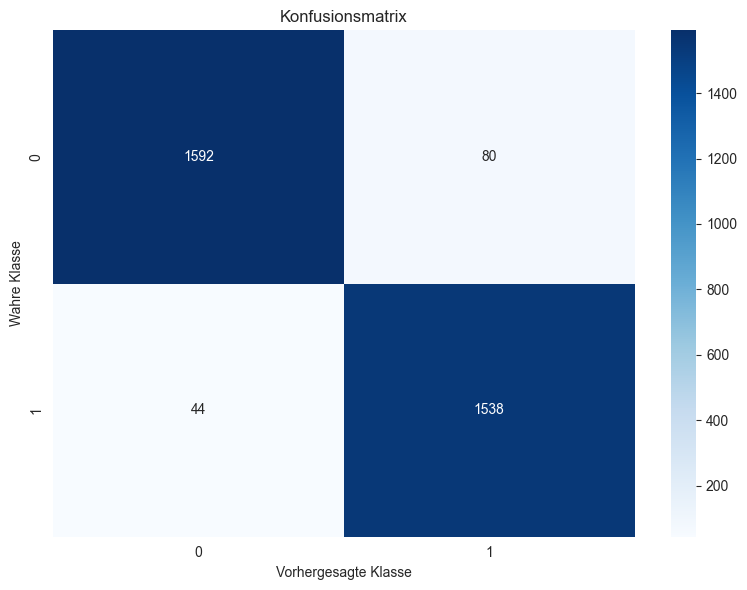

In [27]:
test_model(light_model, test_loader_light)

Test Accuracy: 0.9481

 Classification Report:
              precision    recall  f1-score   support

           0     0.9712    0.9264    0.9483      1672
           1     0.9259    0.9709    0.9479      1582

    accuracy                         0.9481      3254
   macro avg     0.9485    0.9487    0.9481      3254
weighted avg     0.9491    0.9481    0.9481      3254



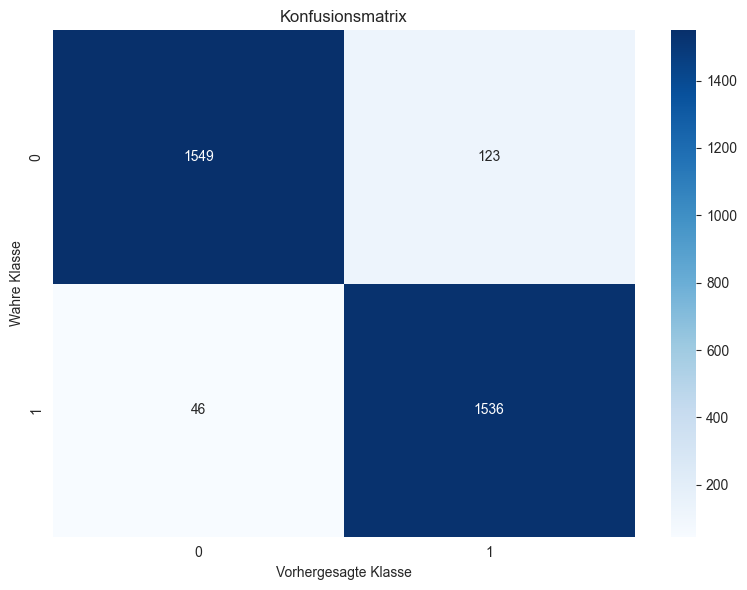

In [28]:
test_model(medium_model, test_loader_medium)

Test Accuracy: 0.9530

 Classification Report:
              precision    recall  f1-score   support

           0     0.9859    0.9217    0.9527      1672
           1     0.9225    0.9861    0.9533      1582

    accuracy                         0.9530      3254
   macro avg     0.9542    0.9539    0.9530      3254
weighted avg     0.9551    0.9530    0.9530      3254



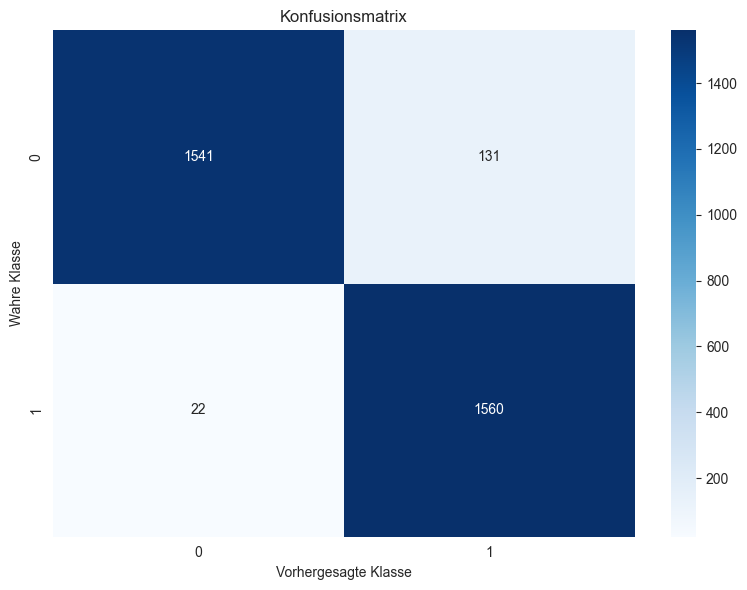

In [29]:
test_model(strong_model, test_loader_strong)

<h1> Visualisierung </h1>

<h2> Transfomration </h2>

In [57]:
# Beispielpfad zu einem Bild im Datensatz (original, unbearbeitet)
image_path = os.path.join(BASE, "data", "KGT_pitting", "P (9).png")
original_image = Image.open(image_path).convert("RGB")

In [58]:
image = r"/Users/blk/Documents/dev/Python/Seminar_KIP/Pitting_Detection-1/images/Oel_pit_h.jpg"
image = Image.open(image).convert("RGB")
image_tensor = test_transform(image)
#image_tensor = image_tensor.unsqueeze(0)

image_tensor.size()


torch.Size([3, 150, 150])

In [59]:
# Bild transformieren
light_tensor = train_transform_light(original_image)
medium_tensor =  train_transform_medium(original_image)
strong_tensor = train_transform_strong(original_image)

In [60]:
def transform_img(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).reshape(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).reshape(-1, 1, 1)
    unnormalized_tensor = tensor * std + mean
    transformed_image = unnormalized_tensor.permute(1, 2, 0).numpy().clip(0, 1)
    return transformed_image

img_light = transform_img(light_tensor)
img_medium = transform_img(medium_tensor)
img_strong = transform_img(strong_tensor)

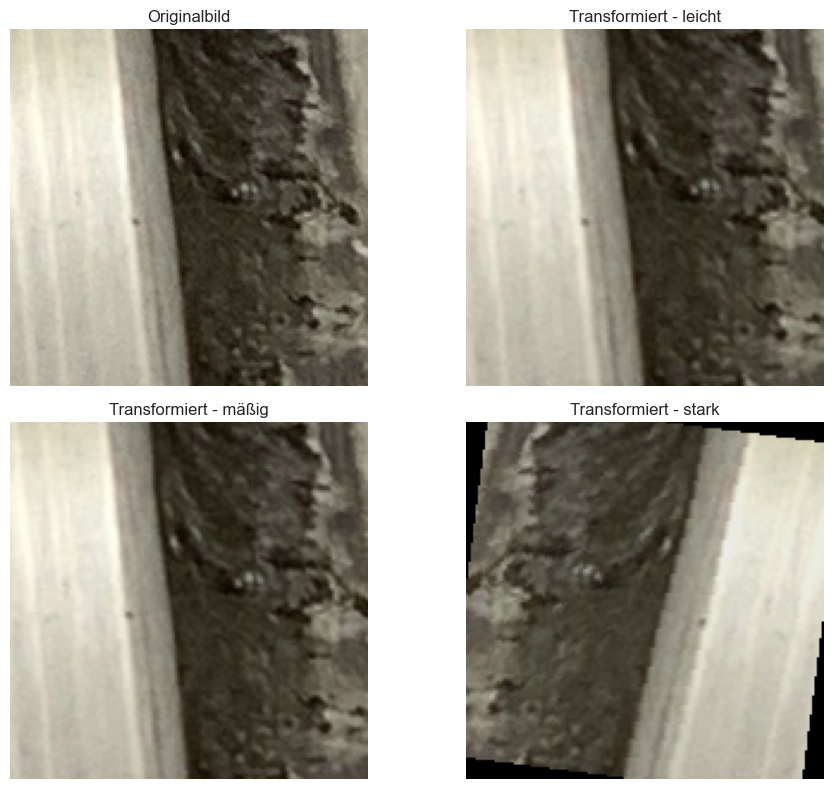

In [61]:
# Bild transformieren
light_tensor = train_transform_light(original_image)
medium_tensor =  train_transform_medium(original_image)
strong_tensor = train_transform_strong(original_image)


img_light = transform_img(light_tensor)
img_medium = transform_img(medium_tensor)
img_strong = transform_img(strong_tensor)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Originalbild")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_light)
axes[0, 1].set_title("Transformiert - leicht")
axes[0, 1].axis("off")

axes[1, 0].imshow(img_medium)
axes[1, 0].set_title("Transformiert - mäßig")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_strong)
axes[1, 1].set_title("Transformiert - stark")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


<h2> Inferenz </h2>

In [62]:
for i in range(100): 
    image_tensor, label = test_set_strong[i] 
    if label == 1: 
        print(i)
        break 

0


In [63]:
image_tensor, label = test_set_light[32] 
label

1

In [64]:
image_tensor2 = image_tensor

In [65]:
image_tensor_batched = image_tensor.unsqueeze(0)
image_tensor_batched
image_tensor.size()

torch.Size([3, 150, 150])

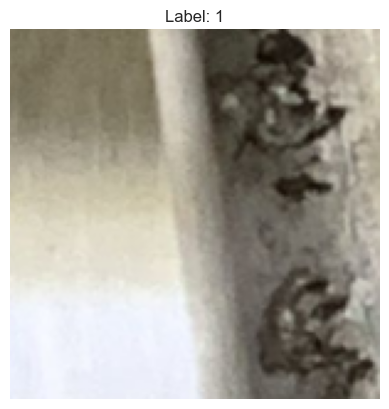

In [66]:
# Unnormalize the image (reverse the normalization applied in the transform)
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
unnormalized_image = image_tensor * std[:, None, None] + mean[:, None, None]


image_np = unnormalized_image.permute(1, 2, 0).numpy()

# Display the image
plt.imshow(image_np)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


In [ ]:
def plot_heatmap(model, img_tensor):

    gradients = []
    
    if img_tensor.shape != (1, 3, resize, resize):
        if img_tensor.shape == (3, resize, resize):
                image_tensor_batched = img_tensor.unsqueeze(0)
        else:
            raise ValueError(f"Unerwartete Bildgröße: {img_tensor.shape}")
    else:
        image_tensor_batched = img_tensor

    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    unnormalized_image = img_tensor * std[:, None, None] + mean[:, None, None]

    image_np = unnormalized_image.permute(1, 2, 0).numpy()


    def save_gradient(grad):
        gradients.append(grad)

    #Forward hook for activations
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)
        output.register_hook(save_gradient)

    # Register the hook to the last conv layer of ResNet18
    if model_used == "cnn":
        target_layer = model.conv2
    elif model_used == "resnet18":
        target_layer = model.layer4
    hook = target_layer.register_forward_hook(forward_hook)

    # Forward pass
    output = model(image_tensor_batched)
    pred_class = output.argmax(dim=1).item()

    #Backward pass for Grad-CAM 
    model.zero_grad()
    output[0, pred_class].backward()

    # Get activations and gradients 
    grads_val = gradients[0][0].cpu().detach().numpy()  # (C, H, W)
    acts_val = activations[0][0].cpu().detach().numpy()  # (C, H, W)

    # Compute the weights and CAM
    weights = np.mean(grads_val, axis=(1, 2))  # Global average pooling
    cam = np.zeros(acts_val.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts_val[i, :, :]

    #Normalize and resize the CAM 
    cam = np.maximum(cam, 0)  # ReLU
    cam = cam - cam.min()
    cam = cam / cam.max()
    cam = cv2.resize(cam, (resize, resize))

    # Overlay the heatmap on the image 
    #img_np = np.array(image.resize((224, 224)))  # Original image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    inverted_heatmap = cv2.bitwise_not(heatmap)
    image_uint8 = (image_np * 255).astype(np.uint8)
    overlay = heatmap * 0.4 + image_uint8 * 0.6
    overlay = np.uint8(overlay)

    # Show the result 
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.title(f"Predicted: {pred_class} ({'Pitting' if pred_class == 1 else 'No Defect'})")
    plt.axis('off')
    plt.show()

    # Cleanup
    hook.remove()

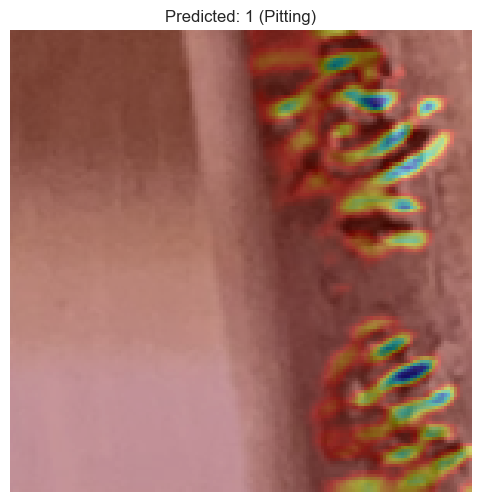

In [70]:
plot_heatmap(light_model, image_tensor)

In [49]:
dfs = []
for name in ["light", "medium", "strong"]:
    metric = load_metrics(name)
    epochs = list(range(1, num_epochs + 1))
    df = pd.DataFrame({
        "epoch": epochs,
        "train_loss": metric["train_loss"],
        "val_loss": metric["val_loss"],
        "transformation": [name] * len(metric["train_loss"])
    })
    dfs.append(df)


losses = pd.concat(dfs, ignore_index=True)



In [50]:
df_melted = losses.melt(id_vars=['epoch', 'transformation'], 
                    value_vars=['train_loss', 'val_loss'],
                    var_name='Loss Type', 
                    value_name='Loss')

df_melted

,epoch,transformation,Loss Type,Loss
0,1,light,train_loss,498.803103
1,2,light,train_loss,363.297469
2,3,light,train_loss,310.018715
3,4,light,train_loss,274.642514
4,5,light,train_loss,237.377820
...,...,...,...,...
85,11,strong,val_loss,34.430613
86,12,strong,val_loss,34.307834
87,13,strong,val_loss,31.614301
88,14,strong,val_loss,32.587583


/var/folders/sc/fn7t0bc17xsbfl68lnhstkp00000gn/T/ipykernel_13376/1445455251.py:2: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data=df_melted, x='epoch', y='Loss',


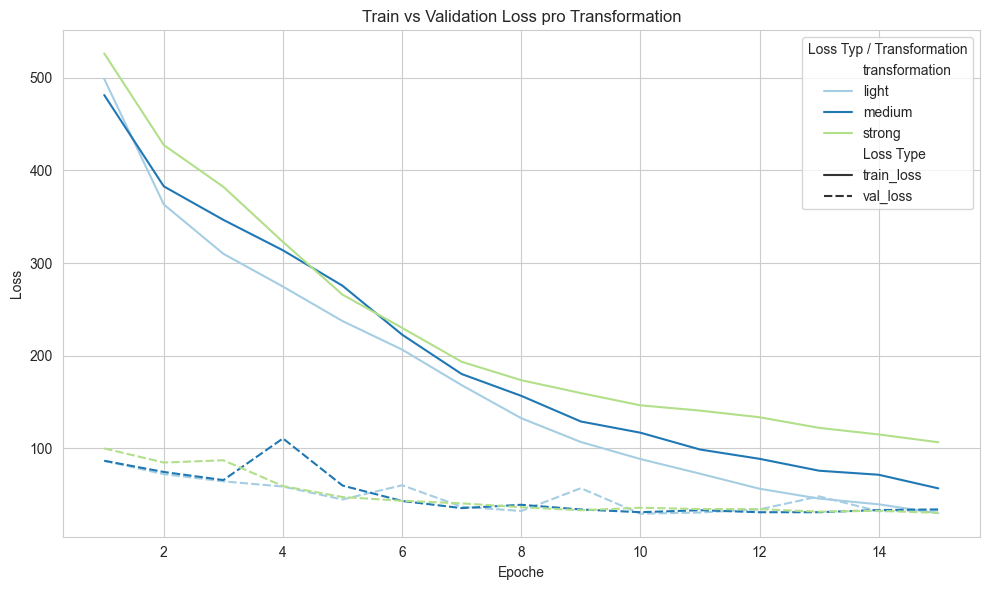

In [51]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='epoch', y='Loss',
             hue='transformation', style='Loss Type', markers=False, dashes=True, palette=sns.color_palette("Paired"))

plt.title('Train vs Validation Loss pro Transformation')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend(title='Loss Typ / Transformation')
plt.tight_layout()
plt.show()

<h2> GridSearchCV </h2>

In [ ]:
# data has to be transformed into a format that sklearn can deal with
X_train_list = []
y_train_list = []
train = ConcatDataset([train_set_light, val_set_light])
for i in range(len(train)):
    data, label = train[i]
    X_train_list.append(data.numpy()) # Convert to NumPy array
    y_train_list.append(label) # Convert to NumPy array

X_train = np.array(X_train_list).astype(np.float32)
y_train = np.array(y_train_list).astype(np.int64)

X_test_list = []
y_test_list = []
for i in range(len(test_set_light)):
    data, label = test_set_light[i]
    X_test_list.append(data.numpy())
    y_test_list.append(label)
X_test = np.array(X_test_list).astype(np.float32)
y_test = np.array(y_test_list).astype(np.int64)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
net = NeuralNetClassifier(Net(), criterion=nn.CrossEntropyLoss(), optimizer=torch.optim.SGD, verbose=0) # initalize the model
# define the param grid for the grid search
param_grid = {
    'lr': [0.01, 0.001],
    'max_epochs': [5, 15],
    'module__dropout': [0.0, 0.2],
    'batch_size': [16, 32],
    'optimizer': [torch.optim.Adam, torch.optim.SGD]
}

# metrics for the gridsearch
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',       
    'f1': 'f1',               
}

# will be 5-fold cv and the refit criterion is accuracy
grid_search = GridSearchCV(estimator=net, param_grid=param_grid, cv=StratifiedKFold(n_splits=5), scoring=scoring, refit="accuracy", n_jobs=4, verbose=3)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Best Parameters and Score ---")
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy on cross-validation set: ", grid_search.best_score_)

print("\n--- Evaluation on Test Set (using the best model) ---")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')    
f1 = f1_score(y_test, y_pred, average='binary')             

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

X_train shape: (18431, 3, 150, 150), y_train shape: (18431,)
X_test shape: (3254, 3, 150, 150), y_test shape: (3254,)
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 4/5] END batch_size=32, lr=0.001, max_epochs=5, module__dropout=0.0, optimizer=<class 'torch.optim.sgd.SGD'>; accuracy: (test=0.748) f1: (test=0.775) precision: (test=0.699) recall: (test=0.870) total time=14.5min
[CV 2/5] END batch_size=32, lr=0.001, max_epochs=5, module__dropout=0.0, optimizer=<class 'torch.optim.sgd.SGD'>; accuracy: (test=0.751) f1: (test=0.770) precision: (test=0.714) recall: (test=0.835) total time=14.5min
[CV 1/5] END batch_size=32, lr=0.001, max_epochs=5, module__dropout=0.0, optimizer=<class 'torch.optim.sgd.SGD'>; accuracy: (test=0.701) f1: (test=0.686) precision: (test=0.718) recall: (test=0.657) total time=14.5min
[CV 3/5] END batch_size=32, lr=0.001, max_epochs=5, module__dropout=0.0, optimizer=<class 'torch.optim.sgd.SGD'>; accuracy: (test=0.692) f1: (test=0.750) precision: (te

In [ ]:
cv_results = pd.read_csv("../cv_results/cv_results.csv", index_col=0) # load the cv results
avg_acc = cv_results.groupby("fold_id")["test_accuracy"].mean().rename("avg_test_accuracy") # calculate the average accuracy per paramter combination
avg_recall = cv_results.groupby("fold_id")["test_recall"].mean().rename("avg_test_recall") # calculate the average recall per paramter combination
param_info = cv_results[["fold_id", "batch_size", "lr", "max_epochs", "module__dropout", "optimizer"]].drop_duplicates()
# merge the averages with the corresponding parameter combination
summary = param_info.merge(pd.concat([avg_acc, avg_recall], axis=1), on="fold_id").sort_values(by=["avg_test_recall", "avg_test_accuracy"], ascending=False).round(4)
pd.set_option('display.width', 200)
print(summary)
summary.to_csv("../cv_results/avg_cv_results_sorted.csv", index=False) # save summary as csv

    fold_id  batch_size     lr  max_epochs  module__dropout optimizer  avg_test_accuracy  avg_test_recall
13       13          16  0.010          15              0.2       sgd             0.9586           0.9660
0         0          16  0.001           5              0.0      adam             0.9340           0.9606
4         4          16  0.001          15              0.0      adam             0.9482           0.9522
12       12          16  0.010          15              0.0       sgd             0.9442           0.9488
6         6          16  0.001          15              0.2      adam             0.9390           0.9484
2         2          16  0.001           5              0.2      adam             0.9328           0.9416
21       21          32  0.010          15              0.2       sgd             0.9232           0.9308
19       19          32  0.010          15              0.0       sgd             0.9100           0.9156
15       15          32  0.010           5    

In [ ]:
"""print("\n--- Detailed Cross-Validation Results  ---")
results = grid_search.cv_results_
# Sort by the refit metric (accuracy in this case)
sorted_indices = np.argsort(results['rank_test_accuracy'])
for i in sorted_indices:
    print(f"Rank {results['rank_test_accuracy'][i]}:")
    print(f"  Params: {results['params'][i]}")
    print(f"  Mean Accuracy: {results['mean_test_accuracy'][i]:.4f} (std: {results['std_test_accuracy'][i]:.4f})")
    print(f"  Mean Precision: {results['mean_test_precision'][i]:.4f} (std: {results['std_test_precision'][i]:.4f})")
    print(f"  Mean Recall: {results['mean_test_recall'][i]:.4f} (std: {results['std_test_recall'][i]:.4f})")
    print(f"  Mean F1-score: {results['mean_test_f1'][i]:.4f} (std: {results['std_test_f1'][i]:.4f})")
    print("-" * 30)"""


--- Detailed Cross-Validation Results  ---
Rank 1:
  Params: {'lr': 0.01, 'max_epochs': 3}
  Mean Accuracy: 0.5846 (std: 0.0948)
  Mean Precision: 0.4916 (std: 0.2508)
  Mean Recall: 0.7524 (std: 0.3800)
  Mean F1-score: 0.5914 (std: 0.2964)
------------------------------
Rank 2:
  Params: {'lr': 0.01, 'max_epochs': 2}
  Mean Accuracy: 0.5508 (std: 0.1021)
  Mean Precision: 0.3702 (std: 0.3037)
  Mean Recall: 0.5566 (std: 0.4563)
  Mean F1-score: 0.4432 (std: 0.3621)
------------------------------
Rank 3:
  Params: {'lr': 0.1, 'max_epochs': 3}
  Mean Accuracy: 0.5137 (std: 0.0627)
  Mean Precision: 0.3389 (std: 0.2767)
  Mean Recall: 0.6000 (std: 0.4899)
  Mean F1-score: 0.4332 (std: 0.3537)
------------------------------
Rank 4:
  Params: {'lr': 0.1, 'max_epochs': 2}
  Mean Accuracy: 0.5130 (std: 0.0628)
  Mean Precision: 0.3386 (std: 0.2765)
  Mean Recall: 0.6000 (std: 0.4899)
  Mean F1-score: 0.4329 (std: 0.3535)
------------------------------
